In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [88]:
data = pd.read_csv('../M1_final.csv')

In [89]:
# Drop unnecessary features
data.drop(columns=['TAIL_NUM', 'DEP_TIME_M', 'TAXI_OUT'], inplace=True)

# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

# Drop null rows
data.dropna(inplace=True)

## Feature engineering

In [90]:
def get_time_of_day(minutes):
    if 300 <= minutes < 720:        # 5:00am - 11:59am
        return 'Morning'
    elif 720 <= minutes < 1020:     # 12:00pm - 4:59pm
        return 'Afternoon'
    elif 1020 <= minutes < 1260:    # 5:00pm - 8:59pm
        return 'Evening'
    else:                           # 9:00pm - 4:59am
        return 'Night'
    

data['time_of_day'] = data['CRS_DEP_M'].apply(get_time_of_day)


### Temporal lag feature

In [91]:
# Function to create temporal features
def create_temporal_features(df):

    df = df.copy()
    
    # Create a new date_order column to sort data according to date time
    df['date_order'] = df['MONTH'] * 100 + df['DAY_OF_MONTH']
    
    # Sort by destination, date, then departure time
    df = df.sort_values(["DEST", "date_order", "CRS_DEP_M"])
    
    # Previous flight delay at same destination
    df["prev_delay"] = df.groupby("DEST")["is_delayed"].shift(1)
    
    # Rolling delay rate over last 3 flights at same destination
    df["rolling_delay_rate_3"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Rolling delay rate over last 5 flights at same destination
    df["rolling_delay_rate_5"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Fill NaN values from the shift operation
    df["prev_delay"] = df["prev_delay"].fillna(0)
    
    # Drop temporary date_order column
    df = df.drop('date_order', axis=1)
    
    return df

## Stratified train test split

In [92]:
# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

x = data.drop('is_delayed', axis=1)
y = data['is_delayed']

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_index, test_index in splitter.split(data, data['is_delayed']):
    # Split the data first
    train_data = data.iloc[train_index].copy()
    test_data = data.iloc[test_index].copy()
    
    # Apply temporal features separately to avoid leakage
    train_data = create_temporal_features(train_data)
    test_data = create_temporal_features(test_data)
    
    # Now split into X and y
    x_train = train_data.drop('is_delayed', axis=1)
    y_train = train_data['is_delayed']
    x_test = test_data.drop('is_delayed', axis=1)
    y_test = test_data['is_delayed']

## Wind direction transformer

In [93]:
class WindDirectionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Wind'):
        self.column = column
        self.wind_dict = {
            'NNW': 340, 'CALM': 0, 'NNE': 20, 'NE': 45, 'VAR': 0, 'WSW': 230, 
            'S': 180, 'SSW': 200, 'WNW': 290, 'ESE': 115, 'N': 360, 'SW': 225, 
            'E': 90, 'W': 270, 'SSE': 155, 'ENE': 70, 'NW': 315, 'SE': 135
        }

    def fit(self, X, y=None):
        return self
    

    def transform(self, X):
        X = X.copy()
        # Map wind directions to degrees
        X['wind_deg'] = X[self.column].map(self.wind_dict)
        # Convert to radians
        X['wind_rad'] = np.deg2rad(X['wind_deg'])
        #Compute sin and cos
        X['wind_sin'] = np.sin(X['wind_rad'])
        X['wind_cos'] = np.cos(X['wind_rad'])
        # Drop original columns
        X = X.drop(columns=[self.column, 'wind_deg', 'wind_rad'])
        return X

## Dew Point Transformer

In [94]:
class DewPointTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Dew Point'):
        self.column = column
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # Clean column
        X[self.column] = (
            X[self.column].astype(str).str.replace('\xa0', '', regex=False).str.strip()
        )
        # Convert them into numeric values
        X[self.column] = pd.to_numeric(X[self.column], errors='coerce')

        return X

In [95]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('Wind transformer', WindDirectionTransformer(column='Wind'), ['Wind']),
    ('Dew Point Transformer', DewPointTransformer(column='Dew Point'), ['Dew Point']),
    ('OrdinalEncoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['DEST', 'OP_UNIQUE_CARRIER', 'Condition']),
    ('OneHotEncoder', OneHotEncoder(handle_unknown='ignore', drop='first'), ['time_of_day'])
], remainder='passthrough')

## LightGBM model

In [96]:
from lightgbm import LGBMClassifier

lightgbm_model = LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    random_state=42,
    verbose=-1  # Suppress warnings
)

## Create pipeline

In [97]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('Preprocessor', preprocessor),
    ('Train LightGBM', lightgbm_model)
])

## Hyperparameter tuning with Optuna

In [98]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

In [99]:
def objective(trial):
    # Define hyperparameter search space for LightGBM
    params = {
        'Train LightGBM__n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'Train LightGBM__max_depth': trial.suggest_int('max_depth', 3, 10),
        'Train LightGBM__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'Train LightGBM__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'Train LightGBM__colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'Train LightGBM__min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 10.0, log=True),
        'Train LightGBM__reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'Train LightGBM__reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
        'Train LightGBM__num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'Train LightGBM__min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'Train LightGBM__verbose': -1,  # Suppress LightGBM output
    }
    
    # Set parameters to the pipeline
    pipe.set_params(**params)
    
    # Perform cross-validation
    # Using accuracy as the metric
    # n_jobs=1 to ensure proper progress display
    cv_scores = cross_val_score(
        pipe, 
        x_train, 
        y_train, 
        cv=5, 
        scoring='accuracy',
        n_jobs=1  # Single job to avoid multiprocessing hiding progress
    )
    
    # Return mean accuracy
    return cv_scores.mean()

In [100]:
# Create Optuna study
study = optuna.create_study(
    direction='maximize',  # Maximize accuracy
    study_name='LightGBM_Hyperparameter_Tuning',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "="*50)
print("Optimization completed!")
print("="*50)

[I 2025-10-29 01:48:53,859] A new study created in memory with name: LightGBM_Hyperparameter_Tuning
Best trial: 0. Best value: 0.9188:   2%|▏         | 1/50 [00:01<01:35,  1.95s/it]

[I 2025-10-29 01:48:55,808] Trial 0 finished with value: 0.9187995962448063 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 0.004207053950287938, 'reg_alpha': 0.05808361216819946, 'reg_lambda': 0.8661761457749352, 'num_leaves': 98, 'min_child_samples': 72}. Best is trial 0 with value: 0.9187995962448063.


Best trial: 0. Best value: 0.9188:   4%|▍         | 2/50 [00:02<01:04,  1.35s/it]

[I 2025-10-29 01:48:56,743] Trial 1 finished with value: 0.9172135853915817 and parameters: {'n_estimators': 108, 'max_depth': 10, 'learning_rate': 0.16967533607196555, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'min_child_weight': 0.00541524411940254, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 0.5247564316322378, 'num_leaves': 76, 'min_child_samples': 32}. Best is trial 0 with value: 0.9187995962448063.


Best trial: 0. Best value: 0.9188:   6%|▌         | 3/50 [00:03<00:56,  1.21s/it]

[I 2025-10-29 01:48:57,778] Trial 2 finished with value: 0.9077447888732637 and parameters: {'n_estimators': 345, 'max_depth': 4, 'learning_rate': 0.027010527749605478, 'subsample': 0.7465447373174767, 'colsample_bytree': 0.7824279936868144, 'min_child_weight': 1.382623217936987, 'reg_alpha': 0.19967378215835974, 'reg_lambda': 0.5142344384136116, 'num_leaves': 97, 'min_child_samples': 9}. Best is trial 0 with value: 0.9187995962448063.


Best trial: 0. Best value: 0.9188:   8%|▊         | 4/50 [00:04<00:50,  1.09s/it]

[I 2025-10-29 01:48:58,694] Trial 3 finished with value: 0.9043734821550894 and parameters: {'n_estimators': 343, 'max_depth': 4, 'learning_rate': 0.012476394272569451, 'subsample': 0.9795542149013333, 'colsample_bytree': 0.9862528132298237, 'min_child_weight': 1.7123375973163988, 'reg_alpha': 0.3046137691733707, 'reg_lambda': 0.09767211400638387, 'num_leaves': 109, 'min_child_samples': 47}. Best is trial 0 with value: 0.9187995962448063.


Best trial: 0. Best value: 0.9188:  10%|█         | 5/50 [00:05<00:42,  1.05it/s]

[I 2025-10-29 01:48:59,391] Trial 4 finished with value: 0.8977296204074537 and parameters: {'n_estimators': 148, 'max_depth': 6, 'learning_rate': 0.011240768803005551, 'subsample': 0.9637281608315128, 'colsample_bytree': 0.7035119926400067, 'min_child_weight': 0.4467752817973907, 'reg_alpha': 0.31171107608941095, 'reg_lambda': 0.5200680211778108, 'num_leaves': 91, 'min_child_samples': 22}. Best is trial 0 with value: 0.9187995962448063.


Best trial: 5. Best value: 0.921823:  12%|█▏        | 6/50 [00:07<01:01,  1.40s/it]

[I 2025-10-29 01:49:01,659] Trial 5 finished with value: 0.9218233859775552 and parameters: {'n_estimators': 488, 'max_depth': 9, 'learning_rate': 0.24420460844911424, 'subsample': 0.9579309401710595, 'colsample_bytree': 0.8391599915244341, 'min_child_weight': 4.869640941520899, 'reg_alpha': 0.0884925020519195, 'reg_lambda': 0.1959828624191452, 'num_leaves': 25, 'min_child_samples': 36}. Best is trial 5 with value: 0.9218233859775552.


Best trial: 5. Best value: 0.921823:  14%|█▍        | 7/50 [00:08<00:54,  1.26s/it]

[I 2025-10-29 01:49:02,634] Trial 6 finished with value: 0.9200388150534582 and parameters: {'n_estimators': 255, 'max_depth': 5, 'learning_rate': 0.16755052359850303, 'subsample': 0.7427013306774357, 'colsample_bytree': 0.7123738038749523, 'min_child_weight': 0.14817820606039092, 'reg_alpha': 0.14092422497476265, 'reg_lambda': 0.8021969807540397, 'num_leaves': 29, 'min_child_samples': 99}. Best is trial 5 with value: 0.9218233859775552.


Best trial: 5. Best value: 0.921823:  16%|█▌        | 8/50 [00:09<00:50,  1.21s/it]

[I 2025-10-29 01:49:03,729] Trial 7 finished with value: 0.9046212767682874 and parameters: {'n_estimators': 409, 'max_depth': 4, 'learning_rate': 0.010189592979395137, 'subsample': 0.9261845713819337, 'colsample_bytree': 0.8827429375390468, 'min_child_weight': 0.8241925264876453, 'reg_alpha': 0.7712703466859457, 'reg_lambda': 0.07404465173409036, 'num_leaves': 66, 'min_child_samples': 16}. Best is trial 5 with value: 0.9218233859775552.


Best trial: 5. Best value: 0.921823:  18%|█▊        | 9/50 [00:11<00:58,  1.44s/it]

[I 2025-10-29 01:49:05,674] Trial 8 finished with value: 0.914635892313108 and parameters: {'n_estimators': 446, 'max_depth': 7, 'learning_rate': 0.030816017044468066, 'subsample': 0.6254233401144095, 'colsample_bytree': 0.7243929286862649, 'min_child_weight': 0.01998634077852888, 'reg_alpha': 0.7296061783380641, 'reg_lambda': 0.6375574713552131, 'num_leaves': 136, 'min_child_samples': 50}. Best is trial 5 with value: 0.9218233859775552.


Best trial: 5. Best value: 0.921823:  20%|██        | 10/50 [00:12<00:49,  1.23s/it]

[I 2025-10-29 01:49:06,434] Trial 9 finished with value: 0.9167677836285009 and parameters: {'n_estimators': 147, 'max_depth': 8, 'learning_rate': 0.13297554090738672, 'subsample': 0.8245108790277985, 'colsample_bytree': 0.9083868719818244, 'min_child_weight': 0.09444574254983566, 'reg_alpha': 0.5227328293819941, 'reg_lambda': 0.42754101835854963, 'num_leaves': 23, 'min_child_samples': 15}. Best is trial 5 with value: 0.9218233859775552.


Best trial: 5. Best value: 0.921823:  22%|██▏       | 11/50 [00:14<00:59,  1.54s/it]

[I 2025-10-29 01:49:08,668] Trial 10 finished with value: 0.9205842531788349 and parameters: {'n_estimators': 492, 'max_depth': 8, 'learning_rate': 0.27047297227177763, 'subsample': 0.8866896138540137, 'colsample_bytree': 0.848068981182222, 'min_child_weight': 4.272274816226787, 'reg_alpha': 0.9597707459454199, 'reg_lambda': 0.28507989151201407, 'num_leaves': 47, 'min_child_samples': 72}. Best is trial 5 with value: 0.9218233859775552.


Best trial: 11. Best value: 0.922815:  24%|██▍       | 12/50 [00:17<01:10,  1.86s/it]

[I 2025-10-29 01:49:11,273] Trial 11 finished with value: 0.9228147487373434 and parameters: {'n_estimators': 499, 'max_depth': 8, 'learning_rate': 0.2734262579715853, 'subsample': 0.8862570177235483, 'colsample_bytree': 0.8411196119345863, 'min_child_weight': 6.899968989684371, 'reg_alpha': 0.9909503209111175, 'reg_lambda': 0.25035033074314605, 'num_leaves': 49, 'min_child_samples': 73}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  26%|██▌       | 13/50 [00:19<01:14,  2.03s/it]

[I 2025-10-29 01:49:13,675] Trial 12 finished with value: 0.9224178006154625 and parameters: {'n_estimators': 489, 'max_depth': 9, 'learning_rate': 0.2969310327971443, 'subsample': 0.8906766271055336, 'colsample_bytree': 0.7959227741587992, 'min_child_weight': 9.48625556900391, 'reg_alpha': 0.5170013476516693, 'reg_lambda': 0.2271390116508784, 'num_leaves': 50, 'min_child_samples': 69}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  28%|██▊       | 14/50 [00:22<01:15,  2.08s/it]

[I 2025-10-29 01:49:15,894] Trial 13 finished with value: 0.9216251207978774 and parameters: {'n_estimators': 415, 'max_depth': 8, 'learning_rate': 0.07459243021342128, 'subsample': 0.8814363008042976, 'colsample_bytree': 0.7730692773810203, 'min_child_weight': 9.903389078668589, 'reg_alpha': 0.9859735780659201, 'reg_lambda': 0.30344630088855795, 'num_leaves': 60, 'min_child_samples': 73}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  30%|███       | 15/50 [00:24<01:21,  2.33s/it]

[I 2025-10-29 01:49:18,793] Trial 14 finished with value: 0.9212778126937143 and parameters: {'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.0780050166260057, 'subsample': 0.887443722235426, 'colsample_bytree': 0.9293529540646579, 'min_child_weight': 8.802790498540574, 'reg_alpha': 0.5795660494660647, 'reg_lambda': 0.0047418765466434865, 'num_leaves': 47, 'min_child_samples': 89}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  32%|███▏      | 16/50 [00:26<01:13,  2.17s/it]

[I 2025-10-29 01:49:20,591] Trial 15 finished with value: 0.9176595468873927 and parameters: {'n_estimators': 386, 'max_depth': 7, 'learning_rate': 0.2986750406976584, 'subsample': 0.7667719743907775, 'colsample_bytree': 0.6018960478612357, 'min_child_weight': 0.0012124232777004015, 'reg_alpha': 0.7884744966085873, 'reg_lambda': 0.31589232270553586, 'num_leaves': 48, 'min_child_samples': 62}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  34%|███▍      | 17/50 [00:29<01:17,  2.34s/it]

[I 2025-10-29 01:49:23,316] Trial 16 finished with value: 0.9191468429133038 and parameters: {'n_estimators': 457, 'max_depth': 9, 'learning_rate': 0.0338365368731356, 'subsample': 0.8472145242741058, 'colsample_bytree': 0.8300635916280871, 'min_child_weight': 0.23282001929331467, 'reg_alpha': 0.6553002062797634, 'reg_lambda': 0.2003681915005748, 'num_leaves': 69, 'min_child_samples': 83}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  36%|███▌      | 18/50 [00:30<01:06,  2.07s/it]

[I 2025-10-29 01:49:24,750] Trial 17 finished with value: 0.9188990851615053 and parameters: {'n_estimators': 332, 'max_depth': 6, 'learning_rate': 0.08867444331288825, 'subsample': 0.9183471047574293, 'colsample_bytree': 0.7507983883065513, 'min_child_weight': 0.05357673059631843, 'reg_alpha': 0.8679715260492223, 'reg_lambda': 0.6560438344215365, 'num_leaves': 38, 'min_child_samples': 60}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  38%|███▊      | 19/50 [00:32<01:00,  1.94s/it]

[I 2025-10-29 01:49:26,388] Trial 18 finished with value: 0.92043572631394 and parameters: {'n_estimators': 260, 'max_depth': 10, 'learning_rate': 0.04591784162456736, 'subsample': 0.8064634504317998, 'colsample_bytree': 0.9703763833608141, 'min_child_weight': 2.076868984721374, 'reg_alpha': 0.44632200845003617, 'reg_lambda': 0.3919300904797557, 'num_leaves': 146, 'min_child_samples': 85}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  40%|████      | 20/50 [00:35<01:05,  2.17s/it]

[I 2025-10-29 01:49:29,092] Trial 19 finished with value: 0.9190970800242548 and parameters: {'n_estimators': 444, 'max_depth': 8, 'learning_rate': 0.1859011281635771, 'subsample': 0.9250148653541173, 'colsample_bytree': 0.8069410260856267, 'min_child_weight': 0.5036370543227395, 'reg_alpha': 0.3852247291293245, 'reg_lambda': 0.9813130867582937, 'num_leaves': 57, 'min_child_samples': 62}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  42%|████▏     | 21/50 [00:36<00:55,  1.92s/it]

[I 2025-10-29 01:49:30,421] Trial 20 finished with value: 0.9119091194487501 and parameters: {'n_estimators': 375, 'max_depth': 7, 'learning_rate': 0.017835726035854482, 'subsample': 0.7761212196779139, 'colsample_bytree': 0.8748862199535327, 'min_child_weight': 2.503957298636716, 'reg_alpha': 0.600546625933633, 'reg_lambda': 0.13740306729154567, 'num_leaves': 116, 'min_child_samples': 98}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  44%|████▍     | 22/50 [00:38<00:57,  2.04s/it]

[I 2025-10-29 01:49:32,757] Trial 21 finished with value: 0.9215259636337721 and parameters: {'n_estimators': 483, 'max_depth': 9, 'learning_rate': 0.23807336241157678, 'subsample': 0.9899134533116726, 'colsample_bytree': 0.8373254638351151, 'min_child_weight': 6.759708200301142, 'reg_alpha': 0.023883768876732187, 'reg_lambda': 0.18313432878019284, 'num_leaves': 33, 'min_child_samples': 35}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  46%|████▌     | 23/50 [00:40<00:54,  2.00s/it]

[I 2025-10-29 01:49:34,668] Trial 22 finished with value: 0.921278156733441 and parameters: {'n_estimators': 462, 'max_depth': 9, 'learning_rate': 0.23424045427947082, 'subsample': 0.945792432914593, 'colsample_bytree': 0.8112029189604187, 'min_child_weight': 3.981009191862214, 'reg_alpha': 0.17660476540036807, 'reg_lambda': 0.2341002823023051, 'num_leaves': 20, 'min_child_samples': 40}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  48%|████▊     | 24/50 [00:43<00:56,  2.17s/it]

[I 2025-10-29 01:49:37,225] Trial 23 finished with value: 0.9211294701358159 and parameters: {'n_estimators': 416, 'max_depth': 9, 'learning_rate': 0.12836328407522804, 'subsample': 0.8692722618334899, 'colsample_bytree': 0.8664816845974899, 'min_child_weight': 4.060776224548078, 'reg_alpha': 0.4051240931591442, 'reg_lambda': 0.3761232404800155, 'num_leaves': 38, 'min_child_samples': 54}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  50%|█████     | 25/50 [00:45<00:52,  2.12s/it]

[I 2025-10-29 01:49:39,222] Trial 24 finished with value: 0.9221210909253992 and parameters: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.21509879049462685, 'subsample': 0.914001732767826, 'colsample_bytree': 0.9440163417454058, 'min_child_weight': 0.939830055113502, 'reg_alpha': 0.9128797962431618, 'reg_lambda': 0.007476090421427217, 'num_leaves': 79, 'min_child_samples': 78}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  52%|█████▏    | 26/50 [00:47<00:50,  2.09s/it]

[I 2025-10-29 01:49:41,248] Trial 25 finished with value: 0.9213279810581557 and parameters: {'n_estimators': 436, 'max_depth': 8, 'learning_rate': 0.1954101548097914, 'subsample': 0.906609641895941, 'colsample_bytree': 0.8951907663827564, 'min_child_weight': 0.63187077691348, 'reg_alpha': 0.8879358099410428, 'reg_lambda': 0.0003634096616631586, 'num_leaves': 80, 'min_child_samples': 78}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  54%|█████▍    | 27/50 [00:49<00:49,  2.14s/it]

[I 2025-10-29 01:49:43,503] Trial 26 finished with value: 0.9208818721167475 and parameters: {'n_estimators': 389, 'max_depth': 7, 'learning_rate': 0.10213887628880443, 'subsample': 0.8581679469648633, 'colsample_bytree': 0.9384174904226629, 'min_child_weight': 1.32495512456382, 'reg_alpha': 0.8828900032352608, 'reg_lambda': 0.07700834220602208, 'num_leaves': 55, 'min_child_samples': 69}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  56%|█████▌    | 28/50 [00:51<00:45,  2.08s/it]

[I 2025-10-29 01:49:45,446] Trial 27 finished with value: 0.9209809924194532 and parameters: {'n_estimators': 465, 'max_depth': 6, 'learning_rate': 0.05611281410102029, 'subsample': 0.9407051561741564, 'colsample_bytree': 0.9290921351860679, 'min_child_weight': 2.7809487176178904, 'reg_alpha': 0.7133372449394492, 'reg_lambda': 0.12544334708451021, 'num_leaves': 72, 'min_child_samples': 91}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  58%|█████▊    | 29/50 [00:53<00:40,  1.92s/it]

[I 2025-10-29 01:49:46,975] Trial 28 finished with value: 0.9209311435204726 and parameters: {'n_estimators': 291, 'max_depth': 8, 'learning_rate': 0.29326658326209676, 'subsample': 0.819180689385424, 'colsample_bytree': 0.9641612383899366, 'min_child_weight': 0.23050148174071963, 'reg_alpha': 0.9153011569951955, 'reg_lambda': 0.24352137764022147, 'num_leaves': 84, 'min_child_samples': 80}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 11. Best value: 0.922815:  60%|██████    | 30/50 [00:54<00:34,  1.71s/it]

[I 2025-10-29 01:49:48,215] Trial 29 finished with value: 0.919494200165999 and parameters: {'n_estimators': 428, 'max_depth': 3, 'learning_rate': 0.14267642349874649, 'subsample': 0.8348027120555579, 'colsample_bytree': 0.9993134344664014, 'min_child_weight': 0.8937263483109397, 'reg_alpha': 0.7871616634818246, 'reg_lambda': 0.43988661912756166, 'num_leaves': 118, 'min_child_samples': 65}. Best is trial 11 with value: 0.9228147487373434.


Best trial: 30. Best value: 0.923261:  62%|██████▏   | 31/50 [00:57<00:39,  2.09s/it]

[I 2025-10-29 01:49:51,186] Trial 30 finished with value: 0.9232606487974891 and parameters: {'n_estimators': 473, 'max_depth': 10, 'learning_rate': 0.2090093366993264, 'subsample': 0.9978968044765303, 'colsample_bytree': 0.7882463489525602, 'min_child_weight': 8.31136600976576, 'reg_alpha': 0.999710000484668, 'reg_lambda': 0.6059822099806645, 'num_leaves': 64, 'min_child_samples': 76}. Best is trial 30 with value: 0.9232606487974891.


Best trial: 30. Best value: 0.923261:  64%|██████▍   | 32/50 [01:00<00:40,  2.27s/it]

[I 2025-10-29 01:49:53,881] Trial 31 finished with value: 0.9217240813678528 and parameters: {'n_estimators': 475, 'max_depth': 10, 'learning_rate': 0.21050022193864812, 'subsample': 0.9929828576255602, 'colsample_bytree': 0.7783404308153616, 'min_child_weight': 9.197103447438701, 'reg_alpha': 0.9943465992377055, 'reg_lambda': 0.594171510607119, 'num_leaves': 63, 'min_child_samples': 76}. Best is trial 30 with value: 0.9232606487974891.


Best trial: 30. Best value: 0.923261:  66%|██████▌   | 33/50 [01:02<00:42,  2.47s/it]

[I 2025-10-29 01:49:56,826] Trial 32 finished with value: 0.9208319126335688 and parameters: {'n_estimators': 470, 'max_depth': 10, 'learning_rate': 0.1585833890748033, 'subsample': 0.8991101042982765, 'colsample_bytree': 0.7371439087564035, 'min_child_weight': 5.433382487071647, 'reg_alpha': 0.8518696175151171, 'reg_lambda': 0.7630160793941664, 'num_leaves': 90, 'min_child_samples': 68}. Best is trial 30 with value: 0.9232606487974891.


Best trial: 30. Best value: 0.923261:  68%|██████▊   | 34/50 [01:06<00:44,  2.81s/it]

[I 2025-10-29 01:50:00,429] Trial 33 finished with value: 0.9227158741772996 and parameters: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.11438059489891692, 'subsample': 0.9674513885382194, 'colsample_bytree': 0.7535675196743996, 'min_child_weight': 2.9069692707583408, 'reg_alpha': 0.940164086631606, 'reg_lambda': 0.7189448305290049, 'num_leaves': 75, 'min_child_samples': 91}. Best is trial 30 with value: 0.9232606487974891.


Best trial: 30. Best value: 0.923261:  70%|███████   | 35/50 [01:09<00:43,  2.91s/it]

[I 2025-10-29 01:50:03,561] Trial 34 finished with value: 0.921079977563695 and parameters: {'n_estimators': 448, 'max_depth': 10, 'learning_rate': 0.10823786628637601, 'subsample': 0.9699272149224121, 'colsample_bytree': 0.6752363465371426, 'min_child_weight': 2.8206988178721026, 'reg_alpha': 0.946666053576675, 'reg_lambda': 0.7334518531181047, 'num_leaves': 55, 'min_child_samples': 93}. Best is trial 30 with value: 0.9232606487974891.


Best trial: 35. Best value: 0.923806:  72%|███████▏  | 36/50 [01:11<00:34,  2.46s/it]

[I 2025-10-29 01:50:04,964] Trial 35 finished with value: 0.9238064923982579 and parameters: {'n_estimators': 215, 'max_depth': 10, 'learning_rate': 0.16871391031911406, 'subsample': 0.9944131473314727, 'colsample_bytree': 0.7588638366992229, 'min_child_weight': 0.015679460350448565, 'reg_alpha': 0.8277469169639433, 'reg_lambda': 0.9066266563376519, 'num_leaves': 43, 'min_child_samples': 83}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  74%|███████▍  | 37/50 [01:12<00:28,  2.23s/it]

[I 2025-10-29 01:50:06,662] Trial 36 finished with value: 0.9220717089374763 and parameters: {'n_estimators': 227, 'max_depth': 10, 'learning_rate': 0.15872544507067818, 'subsample': 0.9928893105193384, 'colsample_bytree': 0.7628125856623313, 'min_child_weight': 0.010597673203513904, 'reg_alpha': 0.8353695399287546, 'reg_lambda': 0.9492169026785966, 'num_leaves': 41, 'min_child_samples': 86}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  76%|███████▌  | 38/50 [01:14<00:24,  2.08s/it]

[I 2025-10-29 01:50:08,402] Trial 37 finished with value: 0.9199396824636195 and parameters: {'n_estimators': 199, 'max_depth': 10, 'learning_rate': 0.11607400249136121, 'subsample': 0.9695101724863847, 'colsample_bytree': 0.7010379746701041, 'min_child_weight': 0.0025240683945899935, 'reg_alpha': 0.9909781171872232, 'reg_lambda': 0.8803476716508973, 'num_leaves': 98, 'min_child_samples': 94}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  78%|███████▊  | 39/50 [01:16<00:22,  2.02s/it]

[I 2025-10-29 01:50:10,284] Trial 38 finished with value: 0.9213280179195549 and parameters: {'n_estimators': 203, 'max_depth': 10, 'learning_rate': 0.18024894677659847, 'subsample': 0.9488679523204314, 'colsample_bytree': 0.637479516253991, 'min_child_weight': 0.023584951559155132, 'reg_alpha': 0.8030908826706835, 'reg_lambda': 0.5806657381191591, 'num_leaves': 75, 'min_child_samples': 84}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  80%|████████  | 40/50 [01:17<00:16,  1.64s/it]

[I 2025-10-29 01:50:11,038] Trial 39 finished with value: 0.9142389687654934 and parameters: {'n_estimators': 115, 'max_depth': 9, 'learning_rate': 0.06196612815033322, 'subsample': 0.9973358551365648, 'colsample_bytree': 0.7444659062570076, 'min_child_weight': 0.0035586776299364946, 'reg_alpha': 0.9327370654567956, 'reg_lambda': 0.8525740351939695, 'num_leaves': 68, 'min_child_samples': 96}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  82%|████████▏ | 41/50 [01:18<00:13,  1.55s/it]

[I 2025-10-29 01:50:12,371] Trial 40 finished with value: 0.9180069287143542 and parameters: {'n_estimators': 325, 'max_depth': 5, 'learning_rate': 0.09661811345900971, 'subsample': 0.675451123557872, 'colsample_bytree': 0.7931629303198806, 'min_child_weight': 0.035918597216890495, 'reg_alpha': 0.7221316903880722, 'reg_lambda': 0.6941892267418807, 'num_leaves': 94, 'min_child_samples': 53}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  84%|████████▍ | 42/50 [01:20<00:12,  1.60s/it]

[I 2025-10-29 01:50:14,095] Trial 41 finished with value: 0.9206340283550171 and parameters: {'n_estimators': 298, 'max_depth': 9, 'learning_rate': 0.25586745920677384, 'subsample': 0.9704015953528174, 'colsample_bytree': 0.8134903014161233, 'min_child_weight': 0.00755282261787342, 'reg_alpha': 0.942228152236841, 'reg_lambda': 0.48843472141978955, 'num_leaves': 50, 'min_child_samples': 74}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  86%|████████▌ | 43/50 [01:22<00:13,  1.88s/it]

[I 2025-10-29 01:50:16,617] Trial 42 finished with value: 0.9213772524618807 and parameters: {'n_estimators': 481, 'max_depth': 10, 'learning_rate': 0.14407592320037155, 'subsample': 0.937935383884625, 'colsample_bytree': 0.797761786935471, 'min_child_weight': 6.530332432896947, 'reg_alpha': 0.2817033569396608, 'reg_lambda': 0.8261102050837629, 'num_leaves': 29, 'min_child_samples': 57}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  88%|████████▊ | 44/50 [01:23<00:10,  1.68s/it]

[I 2025-10-29 01:50:17,824] Trial 43 finished with value: 0.9208820932851431 and parameters: {'n_estimators': 185, 'max_depth': 9, 'learning_rate': 0.2061967784498341, 'subsample': 0.9575348474913699, 'colsample_bytree': 0.8569613293227795, 'min_child_weight': 1.455198125248542, 'reg_alpha': 0.9970878721386108, 'reg_lambda': 0.5683364718640249, 'num_leaves': 43, 'min_child_samples': 69}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  90%|█████████ | 45/50 [01:26<00:09,  1.83s/it]

[I 2025-10-29 01:50:20,026] Trial 44 finished with value: 0.9226659515555203 and parameters: {'n_estimators': 363, 'max_depth': 9, 'learning_rate': 0.25698143672721474, 'subsample': 0.9703709178618123, 'colsample_bytree': 0.761440556856617, 'min_child_weight': 3.516273101546411, 'reg_alpha': 0.8350006809174726, 'reg_lambda': 0.9255150292329701, 'num_leaves': 63, 'min_child_samples': 89}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  92%|█████████▏| 46/50 [01:28<00:08,  2.03s/it]

[I 2025-10-29 01:50:22,500] Trial 45 finished with value: 0.922467858395706 and parameters: {'n_estimators': 368, 'max_depth': 10, 'learning_rate': 0.16831981215570174, 'subsample': 0.9802840842677925, 'colsample_bytree': 0.725746163963543, 'min_child_weight': 0.08867374515608774, 'reg_alpha': 0.8274122133475166, 'reg_lambda': 0.905092846286596, 'num_leaves': 58, 'min_child_samples': 89}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  94%|█████████▍| 47/50 [01:29<00:05,  1.80s/it]

[I 2025-10-29 01:50:23,780] Trial 46 finished with value: 0.9189976402560884 and parameters: {'n_estimators': 163, 'max_depth': 10, 'learning_rate': 0.25207482370636447, 'subsample': 0.9329278232215356, 'colsample_bytree': 0.6926301749431291, 'min_child_weight': 3.7208329428159663, 'reg_alpha': 0.6801126597346143, 'reg_lambda': 0.7676460582724329, 'num_leaves': 64, 'min_child_samples': 81}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  96%|█████████▌| 48/50 [01:31<00:03,  1.86s/it]

[I 2025-10-29 01:50:25,765] Trial 47 finished with value: 0.9216253911148055 and parameters: {'n_estimators': 274, 'max_depth': 9, 'learning_rate': 0.12283740171480327, 'subsample': 0.9658111702449204, 'colsample_bytree': 0.8247628251317103, 'min_child_weight': 0.30509294712424034, 'reg_alpha': 0.8692577840655826, 'reg_lambda': 0.9283688844900084, 'num_leaves': 85, 'min_child_samples': 88}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806:  98%|█████████▊| 49/50 [01:33<00:01,  1.83s/it]

[I 2025-10-29 01:50:27,518] Trial 48 finished with value: 0.9201874770768173 and parameters: {'n_estimators': 234, 'max_depth': 10, 'learning_rate': 0.22859808468024495, 'subsample': 0.9981669196995492, 'colsample_bytree': 0.7571392979054001, 'min_child_weight': 1.8043610807823174, 'reg_alpha': 0.7565397733030238, 'reg_lambda': 0.7007337876448356, 'num_leaves': 73, 'min_child_samples': 99}. Best is trial 35 with value: 0.9238064923982579.


Best trial: 35. Best value: 0.923806: 100%|██████████| 50/50 [01:35<00:00,  1.91s/it]

[I 2025-10-29 01:50:29,566] Trial 49 finished with value: 0.9237069051844944 and parameters: {'n_estimators': 357, 'max_depth': 10, 'learning_rate': 0.19194905958379213, 'subsample': 0.9546893425469166, 'colsample_bytree': 0.7721507336766444, 'min_child_weight': 5.72753396185405, 'reg_alpha': 0.9025780278979814, 'reg_lambda': 0.8210920308576761, 'num_leaves': 32, 'min_child_samples': 92}. Best is trial 35 with value: 0.9238064923982579.

Optimization completed!


## Results

In [109]:
# Display best parameters
print("Best Trial:")
print(f"  Value (Accuracy): {study.best_trial.value:.4f}")
print(f"  Number: {study.best_trial.number}")
print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best Trial:
  Value (Accuracy): 0.9238
  Number: 35

Best Hyperparameters:
  n_estimators: 215
  max_depth: 10
  learning_rate: 0.16871391031911406
  subsample: 0.9944131473314727
  colsample_bytree: 0.7588638366992229
  min_child_weight: 0.015679460350448565
  reg_alpha: 0.8277469169639433
  reg_lambda: 0.9066266563376519
  num_leaves: 43
  min_child_samples: 83


## Training the model with best hyperparameters

In [110]:
# Train final model with best parameters
best_params_with_prefix = {f'Train LightGBM__{key}': value for key, value in study.best_params.items()}
pipe.set_params(**best_params_with_prefix)

# Fit the model
print("Training final model with best parameters...")
pipe.fit(x_train, y_train)

Training final model with best parameters...


,steps,"[('Preprocessor', ...), ('Train LightGBM', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Wind transformer', ...), ('Dew Point Transformer', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluating on test set

In [111]:
# Make predictions on test set
y_pred = pipe.predict(x_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("Test Set Performance")
print("="*50)
print(f"Accuracy:  {100 * accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("="*50)

Test Set Performance
Accuracy:  94.6102
Precision: 0.8088
Recall:    0.8035
F1 Score:  0.8062


### Classification report

In [112]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      7440
           1       0.81      0.80      0.81      1206

    accuracy                           0.95      8646
   macro avg       0.89      0.89      0.89      8646
weighted avg       0.95      0.95      0.95      8646



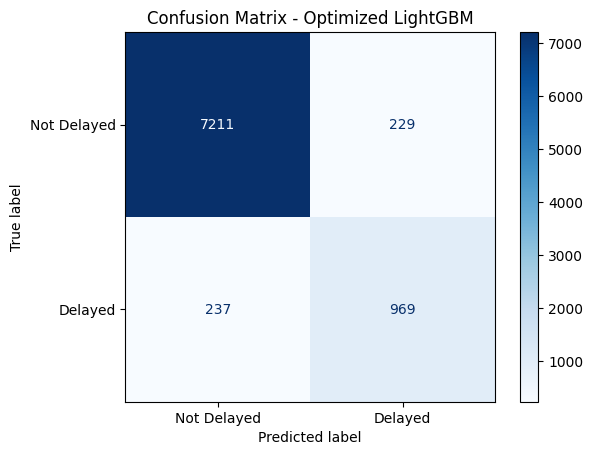

In [113]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Optimized LightGBM')
plt.show()

## ROC AUC Score

ROC AUC Score: 98.3354


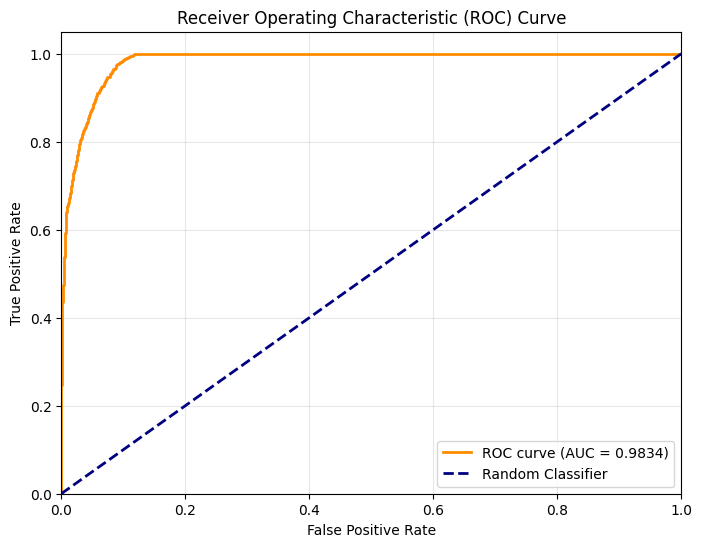

In [114]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get prediction probabilities for ROC curve
y_pred_proba = pipe.predict_proba(x_test)[:, 1]

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC AUC Score: {100 * roc_auc:.4f}')

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Specificity and Sensitivity

In [115]:
# Calculate Specificity (True Negative Rate)
# Specificity = TN / (TN + FP)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)  # Also known as Recall or True Positive Rate

print(f'Specificity (True Negative Rate): {specificity:.4f} or {100 * specificity:.2f}%')
print(f'Sensitivity (True Positive Rate): {sensitivity:.4f} or {100 * sensitivity:.2f}%')

Specificity (True Negative Rate): 0.9692 or 96.92%
Sensitivity (True Positive Rate): 0.8035 or 80.35%


## Save the trained model

In [117]:
import pickle
import os
from datetime import datetime

# Create the saved_models directory if it doesn't exist
save_dir = '../saved_models/'
os.makedirs(save_dir, exist_ok=True)

# Create a timestamp for the filename
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = os.path.join(save_dir, f'LightGBM_model_{timestamp}.pkl')

# Save the entire pipeline (preprocessor + model)
with open(model_filename, 'wb') as file:
    pickle.dump(pipe, file)

print(f"Model saved successfully as: {model_filename}")

# Also save the best parameters for reference
params_filename = os.path.join(save_dir, f'LGBM_BestParams_JFKFlightTakeoff_{timestamp}.pkl')
with open(params_filename, 'wb') as file:
    pickle.dump(study.best_params, file)

print(f"Best parameters saved as: {params_filename}")

Model saved successfully as: ../saved_models/LightGBM_model_20251029_015205.pkl
Best parameters saved as: ../saved_models/LGBM_BestParams_JFKFlightTakeoff_20251029_015205.pkl
